In [ ]:
import sys

# 現在のファイルの親ディレクトリをパスに追加
# 1つ上の階層を追加する場合
# sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))
# あるいは特定のパスを追加
sys.path.append('modulesの絶対パス')

from reconnection import *

dnums =[33, 40, 45, 41]
kappa_0 = [0.0, 1/50, 1/25, 1/10]
dnums_kappa = dict(zip(dnums, kappa_0))

datasets = {}
for dnum in dnums_kappa.keys():
    data_all, x_all, y_all, t_all = read_and_mirror_dataset(dnum)
    datasets[dnum] = {
        "data": data_all,
        "x": x_all,
        "y": y_all,
        "t": t_all
    }



 t =  0.0
 t =  24.99914593508313
 t =  50.00175508540275
 t =  75.00169185151637
 t =  99.99914403012464
 t =  124.99963925892266
 t =  149.99976409032328
 t =  174.99962271803705
 t =  200.00035889693103
 t =  225.00023797501754
 t =  250.00052317579522
 t =  0.0
 t =  25.00051825931449
 t =  50.00050518249738
 t =  75.0017427267578
 t =  99.9994197637584
 t =  124.99909769967884
 t =  149.99909349361954
 t =  175.00002372168916
 t =  200.00056832184652
 t =  224.998991348006
 t =  250.00060486874148
 t =  0.0
 t =  25.000040594344576
 t =  50.00186573264925
 t =  74.99904784558414
 t =  100.00191037427481
 t =  125.00040170251229
 t =  150.0006026696926
 t =  174.99995231279746
 t =  200.00086211254944
 t =  224.99950063172943
 t =  249.99991227757553
 t =  0.0
 t =  25.000658065741465
 t =  50.000813420519066
 t =  75.00105279278277
 t =  100.0005979028801
 t =  124.99957219212867
 t =  149.9998869365893
 t =  174.9990286264271
 t =  199.99963369144507
 t =  224.99917118946684
 t =

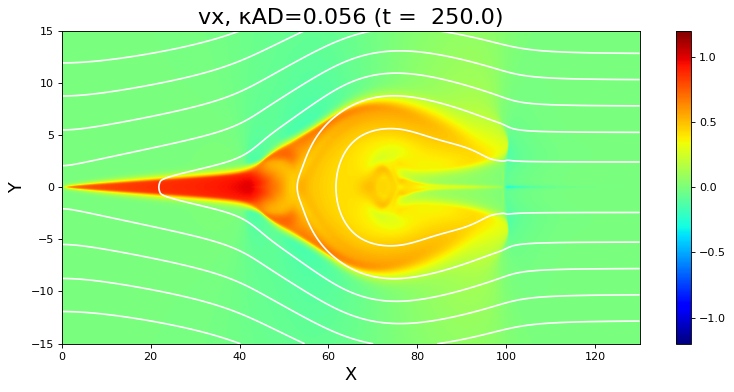

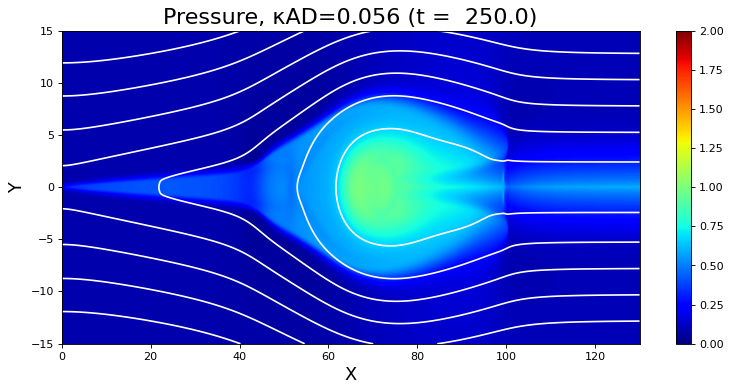

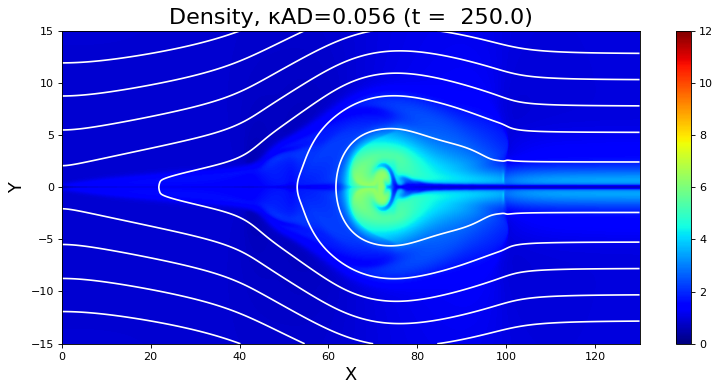

In [4]:
import matplotlib.pyplot as plt
import numpy as np

dataset_num = 47  # dataset number
time_index = 10  # time index

vx=0;vy=1;vz=2;pr=3;ro=4;bx=5;by=6;bz=7;ps=8

data_all = datasets[dataset_num]["data"]
data = data_all[time_index,:,:,:]  # time index
x = datasets[dataset_num]["x"]
y = datasets[dataset_num]["y"]
t = datasets[dataset_num]["t"][time_index]

plot_vx_with_blines(x, y, data, t, component=vx, title_prefix=f'vx, κAD={dnums_kappa[dataset_num]:.3f}') 
plot_vx_with_blines(x, y, data, t, component=pr, title_prefix=f'Pressure, κAD={dnums_kappa[dataset_num]:.3f}')
plot_vx_with_blines(x, y, data, t, component=ro, title_prefix=f'Density, κAD={dnums_kappa[dataset_num]:.3f}')

x=20に最も近いxの値: 19.975000000000016 (インデックス: 400)


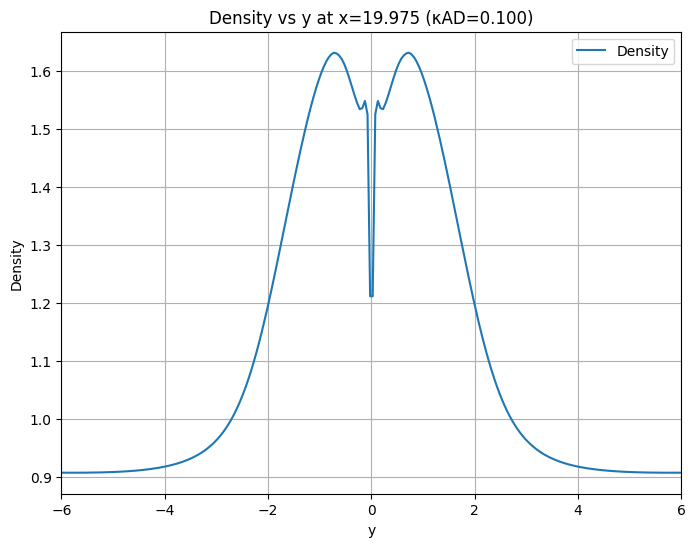

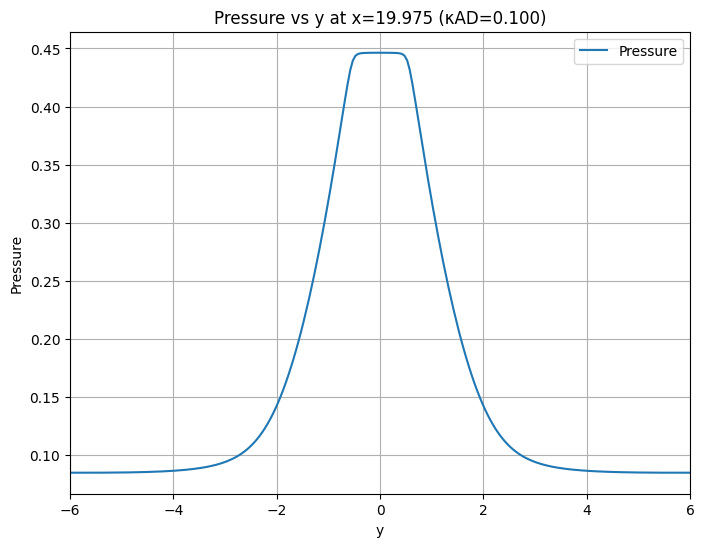

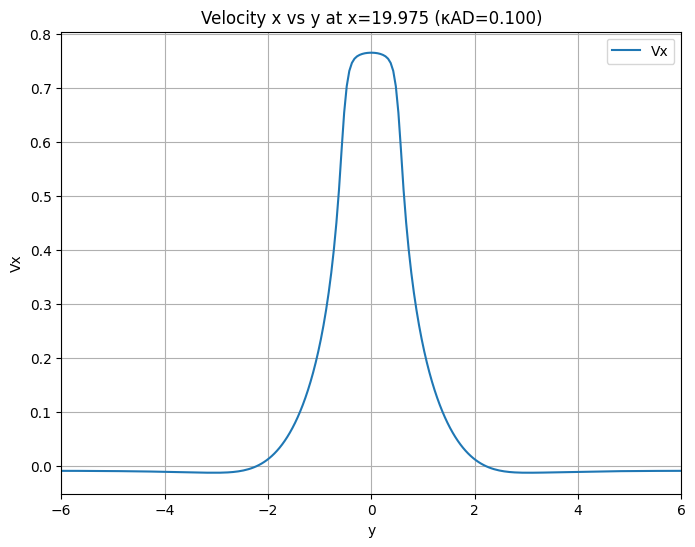

In [6]:
dataset_num = 41  # dataset number
time_index = 10  # time index
data_all = datasets[dataset_num]["data"]
data = data_all[time_index,:,:,:]  # t=40のデータ

# dummy index
vx=0;vy=1;vz=2;pr=3;ro=4;bx=5;by=6;bz=7;ps=8

x = 20

x_index = np.argmin(np.abs(x - datasets[dataset_num]["x"]))
print(f"x={x}に最も近いxの値: {datasets[dataset_num]['x'][x_index]} (インデックス: {x_index})")


# --- プロット ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(datasets[dataset_num]["y"], data[x_index, :, ro], label='Density')
ax.set_xlabel('y')
ax.set_ylabel('Density')
ax.set_title(f'Density vs y at x={datasets[dataset_num]["x"][x_index]:.3f} (κAD={dnums_kappa[dataset_num]:.3f})')
ax.legend()
ax.set_xlim(-6, 6)
ax.grid()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(datasets[dataset_num]["y"], data[x_index, :, pr], label='Pressure')
ax.set_xlabel('y')
ax.set_ylabel('Pressure')
ax.set_title(f'Pressure vs y at x={datasets[dataset_num]["x"][x_index]:.3f} (κAD={dnums_kappa[dataset_num]:.3f})')
ax.legend()
ax.set_xlim(-6, 6)
ax.grid()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(datasets[dataset_num]["y"], data[x_index, :, vx], label='Vx')
ax.set_xlabel('y')
ax.set_ylabel('Vx')
ax.set_title(f'Velocity x vs y at x={datasets[dataset_num]["x"][x_index]:.3f} (κAD={dnums_kappa[dataset_num]:.3f})')
ax.legend()
ax.set_xlim(-6, 6)
ax.grid()

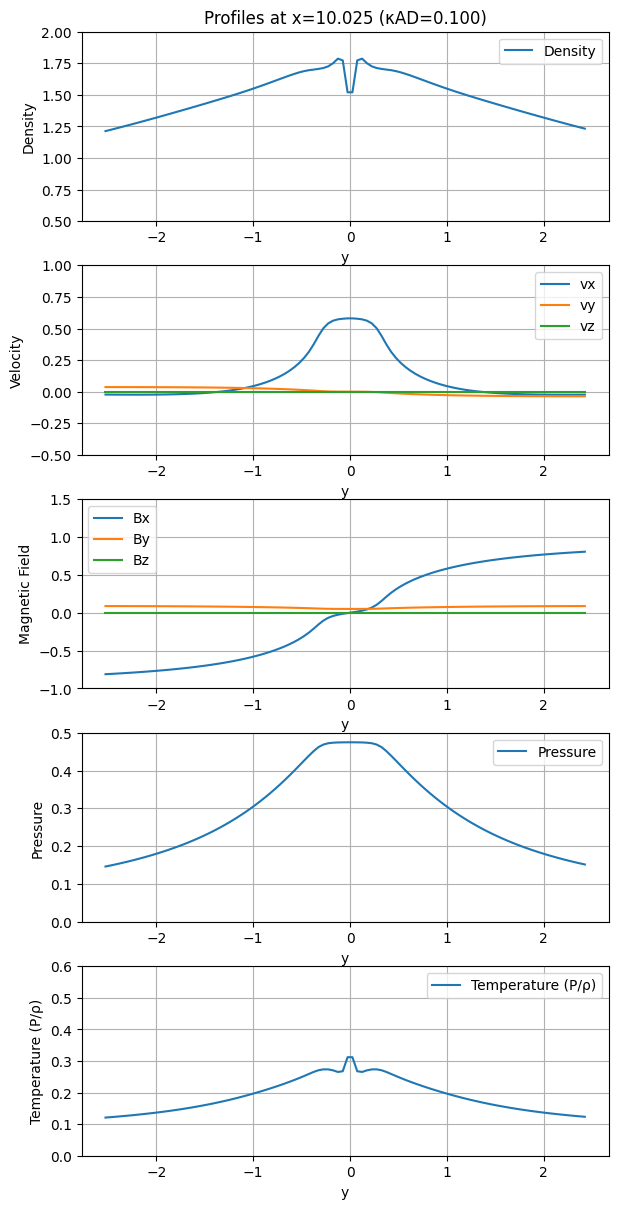

In [8]:
dataset_num = 41  # dataset number
time_index = 6  # time index
data_all = datasets[dataset_num]["data"]
data = data_all[time_index,:,:,:]  # t=40のデータ

x = datasets[dataset_num]["x"]
y = datasets[dataset_num]["y"]
t = datasets[dataset_num]["t"][time_index]

# dummy index
vx=0;vy=1;vz=2;pr=3;ro=4;bx=5;by=6;bz=7;ps=8

x_value_about = 10
x_index = np.argmin(np.abs(x_value_about - datasets[dataset_num]["x"]))
x_value = datasets[dataset_num]["x"][x_index]
y = datasets[dataset_num]["y"]

fig, axes = plt.subplots(5, 1, figsize=(6, 12))
y_min = 250; y_max = 350
axes[0].set_title(f'Profiles at x={datasets[dataset_num]["x"][x_index]:.3f} (κAD={dnums_kappa[dataset_num]:.3f})')
plt.tight_layout()
axes[0].plot(y[y_min:y_max], data[x_index, y_min:y_max, ro], label='Density')
#axes[0].set_title(f'Density vs y at x={datasets[dataset_num]["x"][x_index]:.3f} (κAD={dnums_kappa[dataset_num]:.3f})')
axes[0].set_xlabel('y')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_ylim(0.5, 2.0)
axes[0].grid()
axes[1].plot(y[y_min:y_max], data[x_index, y_min:y_max, vx], label='vx')
axes[1].plot(y[y_min:y_max], data[x_index, y_min:y_max, vy], label='vy')
axes[1].plot(y[y_min:y_max], data[x_index, y_min:y_max, vz], label='vz')
#axes[1].set_title(f'Velocity vs y at x={datasets[dataset_num]["x"][x_index]:.3f} (κAD={dnums_kappa[dataset_num]:.3f})')
axes[1].set_xlabel('y')
axes[1].set_ylabel('Velocity')
axes[1].legend()
axes[1].set_ylim(-0.5, 1.0)
axes[1].grid()
axes[2].plot(y[y_min:y_max], data[x_index, y_min:y_max, bx], label='Bx')
axes[2].plot(y[y_min:y_max], data[x_index, y_min:y_max, by], label='By')
axes[2].plot(y[y_min:y_max], data[x_index, y_min:y_max, bz], label='Bz')
#axes[2].set_title(f'Magnetic Field vs y at x={datasets[dataset_num]["x"][x_index]:.3f} (κAD={dnums_kappa[dataset_num]:.3f})')
axes[2].set_xlabel('y')
axes[2].set_ylabel('Magnetic Field')
axes[2].legend()
axes[2].set_ylim(-1.0, 1.5)
axes[2].grid()
axes[3].plot(y[y_min:y_max], data[x_index, y_min:y_max, pr], label='Pressure')
#axes[3].set_title(f'Pressure vs y at x={datasets[dataset_num]["x"][x_index]:.3f} (κAD={dnums_kappa[dataset_num]:.3f})')
axes[3].set_xlabel('y')
axes[3].set_ylabel('Pressure')
axes[3].legend()
axes[3].set_ylim(0, 0.5)
axes[3].grid()
axes[4].plot(y[y_min:y_max], data[x_index, y_min:y_max, pr]/data[x_index, y_min:y_max, ro], label='Temperature (P/ρ)')
#axes[4].set_title(f'Ps vs y at x={datasets[dataset_num]["x"][x_index]:.3f} (κAD={dnums_kappa[dataset_num]:.3f})')
axes[4].set_xlabel('y')
axes[4].set_ylabel('Temperature (P/ρ)')
axes[4].set_ylim(0, 0.6)
axes[4].legend()
axes[4].grid()
plt.show()